# Volume 2: Non-negative Matrix Factorization
    <Name>
    <Class>
    <Date>

In [115]:
import numpy as np
import cvxpy as cp
from matplotlib import pyplot as plt
import os
import zipfile
from imageio.v3 import imread
import warnings
warnings.filterwarnings("ignore")
from sklearn.decomposition import NMF

## Problems 1-2

In [116]:
class NMFRecommender:

    def __init__(self, random_state=15, rank=3, maxiter=200, tol=1e-3):
        """The parameter values for the algorithm"""
        #initialize
        self.random_state = random_state
        self.rank = rank
        self.maxiter = maxiter
        self.tol = tol
        self.W = None
        self.H = None
    
        
    
    def initialize_matrices(self, m, n):
        """randomly initialize the W and H matrices,"""

        np.random.seed(self.random_state)
        k = self.rank
        self.W = np.random.rand(m, k)
        self.H = np.random.rand(k, n)
        return self.W, self.H

      
    def fit(self, V):
        """Fits W and H weight matrices using CVXPY"""
        #have to get the shape of our matrices
        m, n = V.shape
        W, H = self.initialize_matrices(m, n)
        
        W_var = cp.Variable(self.W.shape, nonneg=True)
        H_var = cp.Variable(self.H.shape, nonneg=True)
        W_var.value = W
        H_var.value = H
        for _ in range(self.maxiter):
            #to measure how much we changed
            W_prev = W.copy()
            H_prev = H.copy()
            #This is the optimization problem
            
            objective_W = cp.Minimize(cp.norm(V - W_var @ H_var.value, "fro"))


            prob_W = cp.Problem(objective_W)
            prob_W.solve()


            #when to stop
            
            objective_H = cp.Minimize(cp.norm(V - W_var.value @ H_var, "fro"))

            prob_H = cp.Problem(objective_H)
            prob_H.solve()
            


            if (np.linalg.norm(W - W_prev, "fro") < self.tol and 
                np.linalg.norm(H - H_prev, "fro") < self.tol):
                break

            self.W = W
            self.H = H

    def reconstruct(self):
        """Reconstruct V matrix for comparison against the original V"""

        return self.W @ self.H
    
    



## Problem 3

In [117]:
def prob3():
    """Run NMF recommender on the grocery store example"""
    V = np.array(
        [
            [0, 1, 0, 1, 2, 2],
            [2, 3, 1, 1, 2, 2],
            [1, 1, 1, 0, 1, 1],
            [0, 2, 3, 4, 1, 1],
            [0, 0, 0, 0, 1, 0]
        ]
    )
    NMF1 = NMFRecommender(rank=2)
    NMF1.fit(V)
    W = NMF1.W
    H = NMF1.H
    count = np.sum(np.argmax(H, axis=0))

    return W, H, count






    

In [118]:
# Implement prob 3 here
prob3()



(array([[0.8488177 , 0.17889592],
        [0.05436321, 0.36153845],
        [0.27540093, 0.53000022],
        [0.30591892, 0.30447436],
        [0.11174128, 0.24989901]]),
 array([[0.9176299 , 0.26414685, 0.71777369, 0.86571503, 0.80707948,
         0.21055058],
        [0.16724303, 0.04670639, 0.03942231, 0.20023081, 0.9985434 ,
         0.37278698]]),
 np.int64(2))

## Problem 4

In [119]:
def get_faces(path="./faces94.zip"):
    '''
    Traverse the specified directory (or zip file) to obtain one image from each subfolder,
    convert each image to grayscale, flatten it, and stack them as columns
    of a data matrix.

    Parameters
    ----------
    path : str
        Directory path (or zip archive) containing the faces94 dataset.

    Returns
    -------
    V : ndarray
        Each column of V is a vectorized face image (flattened to 1D).
    '''
    faces = []        # List to store flattened face images.
    subs = set()      # Track which subfolders have been sampled.

    # Open the zip file containing the dataset.
    with zipfile.ZipFile(path, 'r') as z:
        for info in z.infolist():
            # Skip directories (only process files).
            if info.is_dir():
                continue

            # Only take the *first* image from each subdirectory.
            dn = os.path.dirname(info.filename)
            if dn in subs:
                continue

            # Only process jpg images.
            if not info.filename.lower().endswith("jpg"):
                continue

            subs.add(dn)

            # Read the image from the archive, convert to grayscale, flatten.
            face = imread(z.read(info.filename)).mean(axis=2).ravel()
            faces.append(face)
    
    # Stack face vectors as columns in matrix V.
    return np.transpose(faces)

def show(image, filename, m=200, n=180):
    """Plot the flattened grayscale 'image' of width 'w' and height 'h'.

    Parameters
    ----------
    image : ((mn,) ndarray)
        A flattened image.
    filename: str
        .png filename for saving your figure
    m : int
        The original number of rows in the image.
    n : int
        The original number of columns in the image.

    Returns
    -------
    None
    """
    # Scale image
    image = image / 255
    # Reshape image
    image = np.reshape(image, (m, n))
    # Show image
    plt.imshow(image, cmap="gray")

    # Save the figure
    plt.savefig(filename)

In [128]:
def prob4():
    """Gridsearch over rank, alpha and l1_ratio values to reconstruct 
    image using NMF. Plot all reconstructed images. Determine which set 
    of paramenters best reconstructs the face
    """
    faces = get_faces()
    #components is how it divides up the face, bigger is better but takes longer
    n_components_list = [75]
    alpha_W = [0, .2, .5]
    l1_rat = [0, 1e-5, 1]

    fig, axes = plt.subplots(3, 3)
    axes = axes.flatten()

    best_error = np.inf
    best_params = None

    idx = 0
    #gonna trie every single combination
    for n_components in n_components_list:
        for alpha_w in alpha_W:
            for l1_ratio in l1_rat:
                #this will break into the number of features that I need
                model = NMF(
                    n_components=n_components,
                    init="random",
                    alpha_W=alpha_w,
                    l1_ratio=l1_ratio,
                    max_iter=500,
                    random_state=0
                )

                W = model.fit_transform(faces)
                H = model.components_
                reconstructed = W @ H[:, 2]

                error = np.linalg.norm(faces[:, 2] - reconstructed)
                # want smaller error so reassign if it improves
                if error < best_error:
                    best_error = error
                    best_params = (n_components, alpha_W, l1_ratio)
                    

                #make image again
                axes[idx].imshow(reconstructed.reshape(200, 180), cmap="gray")
                axes[idx].set_title(f"a={alpha_W}, l1={l1_ratio}\nerr={error:.2f}")
                axes[idx].axis("off")

                idx += 1

    plt.suptitle("Reconstruction of 3rd Face (Grid Search)")
    plt.tight_layout()
    plt.savefig("firstpart.png")

    print("Best Parameters:")
    print(f"n_components={best_params[0]}, alpha_W={best_params[1]}, l1_ratio={best_params[2]}")
    print(f"Error = {best_error:.4f}")

    return best_params, best_error

    
    


Best Parameters:
n_components=75, alpha_W=[0, 0.2, 0.5], l1_ratio=1
Error = 2095.0847


((75, [0, 0.2, 0.5], 1), np.float64(2095.084711082172))

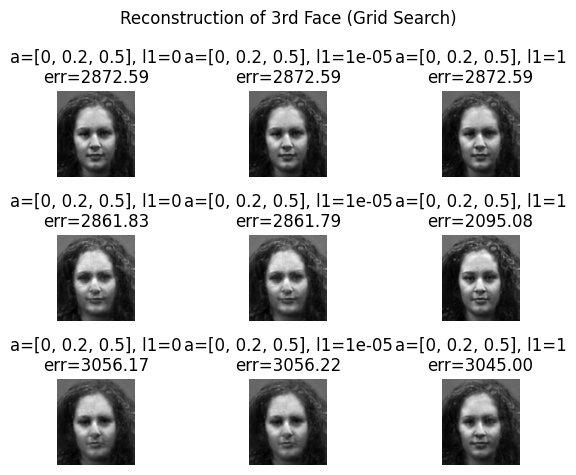

In [129]:
# Implement prob 4 here
prob4()

The parameters that reconstruct the face the best are:
(75, [0, 0.2, 0.5], 1) if I plug them into n, components, and l1

## Problem 5

In [143]:
def prob5():
    """Find the 10 basis faces with the largest coefficients corresponding 
    to the the 2nd and 12th faces in the dataset. Plot these basis faces 
    along with the original image using subplots
    """
    ##gets the faces
    faces = get_faces()
    #make mnf model
    model = NMF(
        n_components=75,
        init="nndsvd",
        max_iter=200,
        random_state=0
    )
    #gets the peices ("W") and H("Instructions")
    W = model.fit_transform(faces)
    H = model.components_

    face_indices = [1, 11]

    for j in face_indices:
        coeffs = H[:, j]
        top10_idx = np.argsort(coeffs)[-10:][::-1]

        fig, axes = plt.subplots(6, 2, figsize=(6, 12))
        axes = axes.flatten()  # makes indexing easy

        axes[0].imshow(faces[:, j].reshape(200, 180), cmap="gray")
        axes[0].set_title(f"original {j + 1}")


        axes[0].axis("off")

        for i, idx in enumerate(top10_idx):
            axes[i+1].imshow(W[:, idx].reshape(200, 180), cmap="gray")
            axes[i+1].set_title(f"{i+1}")
            axes[i+1].axis("off")

        plt.suptitle(f"top 10 basis faces for face {j + 1}")
        plt.tight_layout()
        plt.savefig("prob5.png")


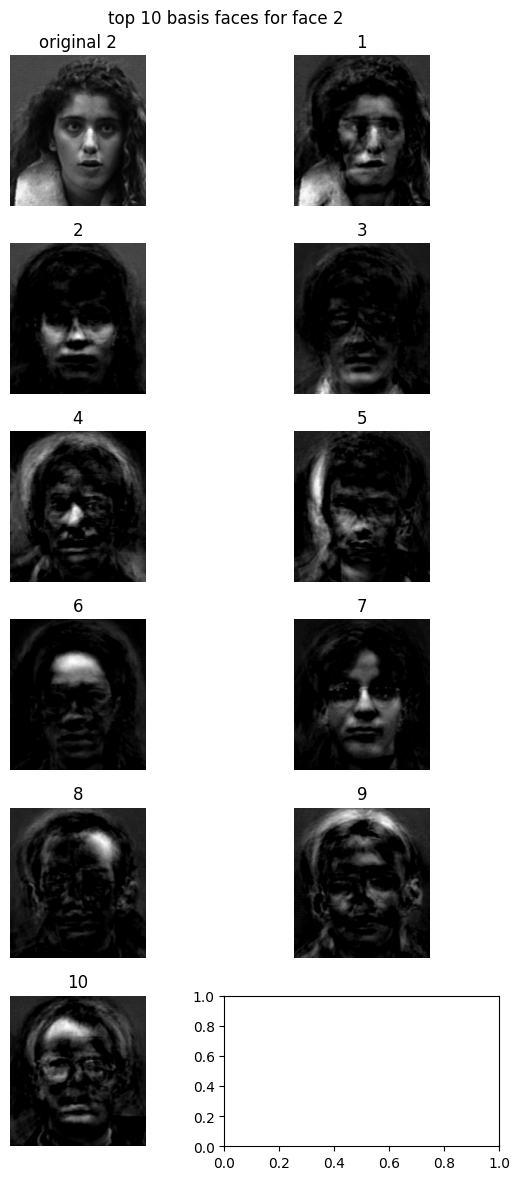

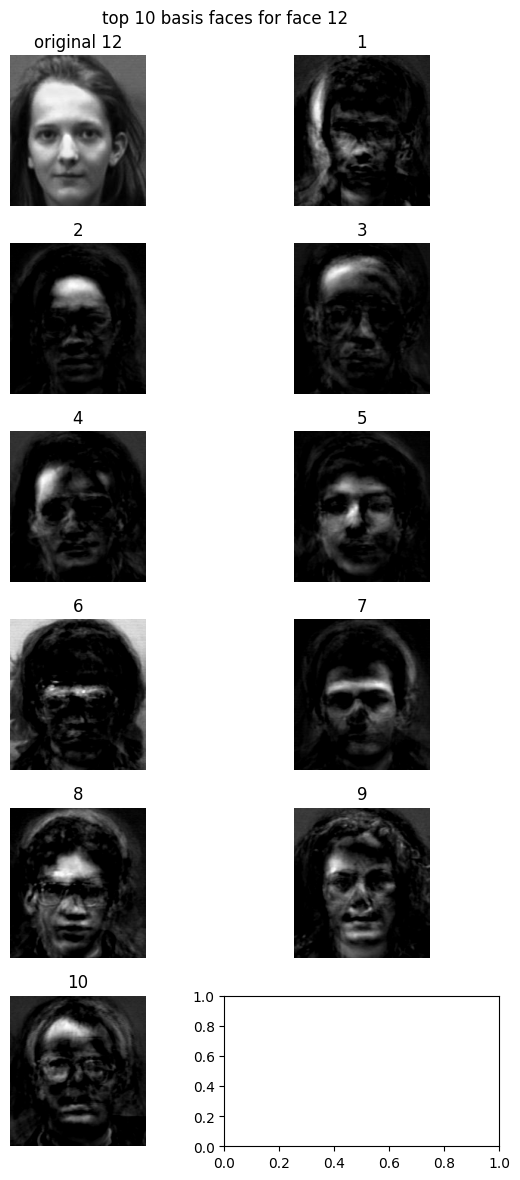

In [145]:
# Implement prob 5 here
prob5()

Write a sentence or two about the differences you notice in the features of the basis faces:
-for face 2, there are certain ones that get the nose and the forehead
 and the hair

 - for the second one, there are ones that get the foreheads and facial features while others focus on the hair because those things are darker and lighter

